In [1]:
import pickle
from pathlib import Path

import cv2
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz
import onnxruntime as ort
from PIL import Image
from tqdm import tqdm

from solar_irradiance.datamodules.cloud_mask import CloudMask
from solar_irradiance.datamodules.sun_mask import SunMask

**Dates**
- clear sky
  - 20140621  # good sample - sunny
  - 20140216
  - 20140223
  - 20140322
- cloudy
  - 20140111
  - 20140129
  - 20140131
  - 20140210
  - 20140218
  - 20140219
  - 20140228
  - 20140301
  - 20140328
  - 20140402  # good sample - partially cloudy
  - 20141122  # good sample - cloudy
- rainy
  - 20140207  # good sample - rainy
  - 20140208
  - 20140209
  - 20140227

In [2]:
day = "28"
month = "09"
month_word = "September"
year = "2014"

data_path = Path("./data")
image_dir = Path(f"./{year}{month}{day}")

df = pd.read_csv("../data/prepared/cleaned_irradiance.csv", parse_dates=["datetime"], index_col="datetime")

image_list = sorted(image_dir.rglob("*.jpg"))[14:-28]

In [3]:
time_shift = 5
history_size = 4
time_window = 15
inference_periods = []

for image_path in tqdm(image_list):
    t = pd.Timestamp(df[df["image_name"] == image_path.name].index[0])
    t_history = [t - pd.Timedelta(minutes=time_shift * i) for i in range(history_size - 1, 0, -1)]
    t_target = t + pd.Timedelta(minutes=time_window)

    if all(map(lambda x: x in df.index, [*t_history, t_target])) and df.loc[t_target]["ghi"] > 0.0:  # noqa C417
        inference_periods.append(
            {
                "history": [
                    {"image_name": df.loc[_t]["image_name"], "irradiance": df.loc[_t]["ghi"]}
                    for _t in sorted([*t_history, t])
                ],
                "target_irradiance": df.loc[t_target]["ghi"],
            }
        )

100%|██████████| 661/661 [00:35<00:00, 18.61it/s]


In [4]:
LATITUDE = 38.642
LONGITUDE = -121.148
CAMERA_ORIENTATION_COMPENSATION = 165
FOCAL_LENGTH = 0.48

INPUT_SHAPE = (128, 128)

US_PACIFIC = pytz.timezone("US/Pacific")


def preprocess(img_data: np.ndarray) -> np.ndarray:
    mean_vec = np.array([0.485, 0.456, 0.406])
    stddev_vec = np.array([0.229, 0.224, 0.225])

    img_data = (img_data / 255 - mean_vec) / stddev_vec
    img_data = np.transpose(img_data, (2, 0, 1))

    return img_data.astype(np.float32)


sun_mask_gen = SunMask(LATITUDE, LONGITUDE, CAMERA_ORIENTATION_COMPENSATION, FOCAL_LENGTH)

cloud_mask = CloudMask(shape=INPUT_SHAPE, method="normalized_blue_red_ratio")

of = cv2.DISOpticalFlow_create(preset=cv2.DISOPTICAL_FLOW_PRESET_FAST)

crop_mask = cv2.circle(
    np.zeros((INPUT_SHAPE[0], INPUT_SHAPE[1], 3), dtype=np.uint8),
    (INPUT_SHAPE[1] // 2, INPUT_SHAPE[0] // 2),
    INPUT_SHAPE[0] // 2,
    color=(1, 1, 1),
    thickness=-1,
)

def bag_of_tricks(period: dict) -> tuple[list, list]:
    source_images = []
    source_irradiances = []
    flow = None
    prev_image = None

    for history_item in period["history"]:
        image_path = Path(image_dir, history_item["image_name"])
        irradiance = history_item["irradiance"]
        source_image = np.asarray(Image.open(image_path))

        source_image = cv2.resize(source_image, INPUT_SHAPE)
        source_image = np.where(crop_mask.astype(bool), source_image, 0)
        input_data = preprocess(source_image)

        # irradiance-based Sun mask
        date = pd.to_datetime(image_path.name[:15], format="%Y%m%d_%H%M%S")
        us_pacific_date = US_PACIFIC.localize(date)
        utc_date = us_pacific_date.astimezone(pytz.utc).strftime("%Y%m%d_%H%M%S")

        sun_mask = sun_mask_gen(image_shape=INPUT_SHAPE, timestamp=utc_date)
        input_data = np.concatenate([input_data, np.transpose(sun_mask, (2, 0, 1))], axis=0)

        input_data[-1] *= irradiance

        # cloud mask
        mask = cloud_mask(image=source_image)
        input_data = np.concatenate([input_data, np.transpose(mask, (2, 0, 1))], axis=0)

        # optical flow
        image = cv2.cvtColor(source_image, cv2.COLOR_RGB2GRAY)
        if prev_image is None:
            prev_image = image.copy()
        flow = of.calc(prev_image, image, flow)
        prev_image = image
        input_data = np.concatenate([input_data, np.transpose(flow, (2, 0, 1))], axis=0)

        source_images.append(input_data)
        source_irradiances.append(irradiance)

    return source_images, source_irradiances


def venitourakis_papatheofanous_preprocess_image(period: dict) -> np.ndarray:
    history_item = period["history"][-1]
    image_path = Path(image_dir, history_item["image_name"])
    source_image = np.asarray(Image.open(image_path))

    source_image = cv2.resize(source_image, INPUT_SHAPE)
    source_image = np.where(crop_mask.astype(bool), source_image, 0)
    input_data = preprocess(source_image)

    # irradiance-based Sun mask
    date = pd.to_datetime(image_path.name[:15], format="%Y%m%d_%H%M%S")
    us_pacific_date = US_PACIFIC.localize(date)
    utc_date = us_pacific_date.astimezone(pytz.utc).strftime("%Y%m%d_%H%M%S")

    sun_mask = sun_mask_gen(image_shape=INPUT_SHAPE, timestamp=utc_date)
    input_data = np.concatenate([input_data, np.transpose(sun_mask, (2, 0, 1))], axis=0)

    return np.expand_dims(input_data, axis=0).astype(np.float32)

def base_preprocess_image(period: dict) -> np.ndarray:
    history_item = period["history"][-1]
    image_path = Path(image_dir, history_item["image_name"])
    source_image = np.asarray(Image.open(image_path))

    source_image = cv2.resize(source_image, INPUT_SHAPE)
    source_image = np.where(crop_mask.astype(bool), source_image, 0)
    input_data = preprocess(source_image)

    return np.expand_dims(input_data, axis=0).astype(np.float32)

In [5]:
target_irradiances = []
bot_irradiance_forecasts = []
presistance_model_irradiance_forecasts = []
papatheofanous_model_irradiance_forecasts = []
venitourakis_model_irradiance_forecasts = []
base_resnet50_model_irradiance_forecasts = []
mlp_model_irradiance_forecasts = []
images = []

# load bot model
bot_sess = ort.InferenceSession("./resnet50.onnx", providers=["CPUExecutionProvider"])

inputs = [i.name for i in bot_sess.get_inputs()]
shapes = [s.shape for s in bot_sess.get_inputs()]

# load MLP model
with open("./mlp_model.pickle", "rb") as f:
    mlp_model = pickle.load(f)

# load Papatheofanous et al. model
papatheofanous_sess = ort.InferenceSession("./papatheofanous_resnet50.onnx", providers=["CPUExecutionProvider"])

# load Venitourakis et al. model
venitourakis_sess = ort.InferenceSession("./venitourakis_xception.onnx", providers=["CPUExecutionProvider"])

# load ResNet50 model without bot
resnet50_sess = ort.InferenceSession("./resnet50_without_bot.onnx", providers=["CPUExecutionProvider"])

for p in tqdm(inference_periods):
    target_irradiance = p["target_irradiance"]
    target_irradiances.append(target_irradiance)
    irradiance_t = p["history"][-1]["irradiance"] # irradiance at time t
    presistance_model_irradiance_forecasts.append(irradiance_t) # presistance model model forecast t_hat = t
    image_path = p["history"][-1]["image_name"]
    images.append(image_path)

    # bag of tricks (bot) model
    source_images, source_irradiances = bag_of_tricks(p)
    image_input = np.array(source_images[-1:], dtype=np.float32)

    bot_output = bot_sess.run(
        None,
        {
            inputs[0]: image_input,
            inputs[1]: np.expand_dims(source_irradiances, axis=0).astype(np.float32),
        },
    )[0][0][0]

    bot_irradiance_forecasts.append(bot_output)

    # Papatheofanous model inference
    image_input = venitourakis_papatheofanous_preprocess_image(p)
    papatheofanous_output = papatheofanous_sess.run(
        None,
        {
            inputs[0]: image_input,
            inputs[1]: np.expand_dims(source_irradiances, axis=0).astype(np.float32),
        },
    )[0][0][0]

    papatheofanous_model_irradiance_forecasts.append(papatheofanous_output)

    # Venitourakis model inference
    venitourakis_output = venitourakis_sess.run(
        None,
        {
            inputs[0]: image_input,
            inputs[1]: np.expand_dims(source_irradiances, axis=0).astype(np.float32),
        },
    )[0][0][0]

    venitourakis_model_irradiance_forecasts.append(venitourakis_output)

    # ResNet50 model inference without bot
    base_image_input = base_preprocess_image(p)
    resnet50_output = resnet50_sess.run(
        None,
        {
            inputs[0]: base_image_input,
            inputs[1]: np.expand_dims(source_irradiances, axis=0).astype(np.float32),
        },
    )[0][0][0]

    base_resnet50_model_irradiance_forecasts.append(resnet50_output)

    # MLP model inference
    mlp_output = mlp_model.predict(np.expand_dims(source_irradiances, axis=0).astype(np.float32))[0]
    mlp_model_irradiance_forecasts.append(float(mlp_output))

  0%|          | 0/652 [00:00<?, ?it/s]/home/mateusz/Research/solar-irradiance/solar_irradiance/datamodules/sun_mask.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  zenith = solarposition["zenith"][0]
/home/mateusz/Research/solar-irradiance/solar_irradiance/datamodules/sun_mask.py:70: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  azimuth = solarposition["azimuth"][0]
  0%|          | 1/652 [00:00<02:26,  4.43it/s]/home/mateusz/Research/solar-irradiance/solar_irradiance/datamodules/sun_mask.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will al

In [6]:
forecasts = {
    "target_irradiances": target_irradiances,
    "bot_irradiance_forecasts": bot_irradiance_forecasts,
    "presistance_model_irradiance_forecasts": presistance_model_irradiance_forecasts,
    "papatheofanous_model_irradiance_forecasts": papatheofanous_model_irradiance_forecasts,
    "venitourakis_model_irradiance_forecasts": venitourakis_model_irradiance_forecasts,
    "base_resnet50_model_irradiance_forecasts": base_resnet50_model_irradiance_forecasts,
    "mlp_model_irradiance_forecasts": mlp_model_irradiance_forecasts,
    "images": images,
}

with open(f"forecasts_{day}_{month}_{year}.pickle", "wb") as f:
    pickle.dump(forecasts, f)

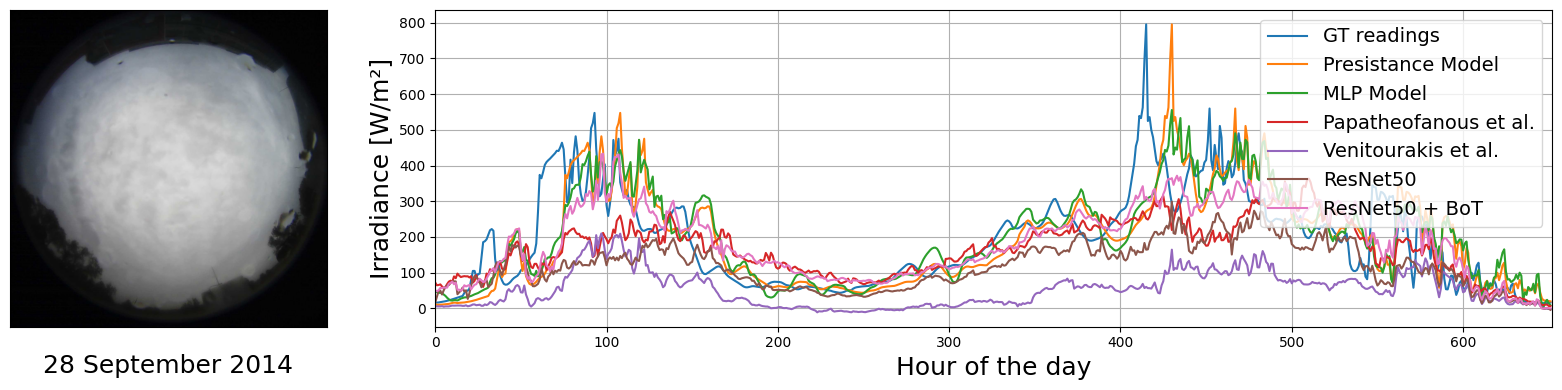

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios": [1, 3]})

ax[0].imshow(np.asarray(Image.open(Path(image_dir, images[len(images) // 2]))))
ax[0].set_xticks([], [])
ax[0].set_yticks([], [])
ax[0].set_xlabel(f"{day} {month_word} {year}", fontsize=18, labelpad=20)

ax[1].plot(target_irradiances, label="GT readings")
ax[1].set_ylabel("Irradiance [W/m²]", fontsize=18)
ax[1].grid(True)
# ax[1].set_ylim(0, 1400)
ax[1].set_xlim(0, len(target_irradiances))
# ax[1].set_xticks(np.arange(0, len(irradiance) + 1, 60), np.arange(6, 21, 1))
ax[1].set_xlabel("Hour of the day", fontsize=18)

presistance_model_lines_plotted = ax[1].plot(presistance_model_irradiance_forecasts, label="Presistance Model")
mlp_model_lines_plotted = ax[1].plot(mlp_model_irradiance_forecasts, label="MLP Model")
papatheofanous_model_lines_plotted = ax[1].plot(papatheofanous_model_irradiance_forecasts, label="Papatheofanous et al.")
venitourakis_model_lines_plotted = ax[1].plot(venitourakis_model_irradiance_forecasts, label="Venitourakis et al.")
base_Resnet50_model_lines_plotted = ax[1].plot(base_resnet50_model_irradiance_forecasts, label="ResNet50")
bot_model_lines_plotted = ax[1].plot(bot_irradiance_forecasts, label="ResNet50 + BoT")

plt.legend(loc="upper right", fontsize=14, ncol=1)
plt.tight_layout()
# plt.savefig(f"{day}_{month}_{year}_Folsom..png", dpi=300)

In [8]:
# fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 2]})

# images_plotted = ax[0].imshow(np.asarray(Image.open(Path(image_dir, images[0]))))
# ax[0].set_xticks([], [])
# ax[0].set_yticks([], [])
# ax[0].set_xlabel(f"{day} {month_word} {year}", fontsize=18, labelpad=20)

# lines_plotted = ax[1].plot([], label="GT readings")
# ax[1].set_ylabel("Irradiance [W/m²]", fontsize=18)
# ax[1].grid(True)
# # ax[1].set_ylim(0, 1400)
# ax[1].set_xlim(0, len(target_irradiances))
# # ax[1].set_xticks(np.arange(0, len(target_irradiances) + 1, 60), np.arange(6, 21, 1))
# ax[1].set_xlabel("Hour of the day", fontsize=18)

# bot_model_lines_plotted = ax[1].plot([], label="BoT irradiance forecasts")

# line_plotted = lines_plotted[0]
# prediction_line_plotted = bot_model_lines_plotted[0]

# plt.legend(loc="upper right", fontsize=14)
# plt.tight_layout()

# factor = 6


# def animate(i):
#     images_plotted.set_array(np.asarray(Image.open(Path(image_dir, images[i * factor]))))
#     line_plotted.set_data((np.arange(i * factor), target_irradiances[: i * factor]))
#     prediction_line_plotted.set_data((np.arange(i * factor), bot_irradiance_forecasts[: i * factor]))
#     return images_plotted, line_plotted, prediction_line_plotted


# ani = animation.FuncAnimation(fig, animate, repeat=True, frames=len(target_irradiances) // factor, interval=50)

# # To save the animation using Pillow as a gif
# writer = animation.PillowWriter(fps=60, metadata=dict(artist="Me"), bitrate=50000)
# ani.save(f"{day}_{month}_{year}_Folsom.gif", writer=writer)

# # plt.show()